# First we will configure our spark session

In [1]:
import os

In [2]:
from pyspark.sql import SparkSession

In [3]:
import pandas as pd
import numpy as np
import json

spark_jars = os.environ.get("SPARK_JARS", "")
jar_list = spark_jars.split(",") if spark_jars else []
s3a_endpoint = os.environ.get("S3A_ENDPOINT", "")
s3a_access_key = os.environ.get("S3A_ACCESS_KEY", "")
s3a_secret_key = os.environ.get("S3A_SECRET_KEY", "")
driver_memory = os.environ.get("SPARK_DRIVER_MEMORY", "4g")

spark = (
    SparkSession.builder
    .appName("Tazama-Dashboard")
    .master("local[*]")
    .config("spark.jars", spark_jars)
    .config("spark.driver.extraClassPath", ":".join(jar_list))
    .config("spark.executor.extraClassPath", ":".join(jar_list))
    .config("spark.hadoop.fs.s3a.endpoint", s3a_endpoint)
    .config("spark.hadoop.fs.s3a.access.key", s3a_access_key)
    .config("spark.hadoop.fs.s3a.secret.key", s3a_secret_key)
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.impl.disable.cache", "true")
    .config("spark.hadoop.fs.s3a.connection.maximum", "100")
    .config("spark.hadoop.fs.s3a.fast.upload", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryo.registrator", "org.apache.spark.HoodieSparkKryoRegistrar")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.driver.memory", driver_memory)
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    .config("spark.memory.fraction", "0.8")
    .config("spark.memory.storageFraction", "0.2")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128mb")
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark Version: {spark.version}")


26/06/02 13:58:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/02 13:58:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
26/06/02 13:58:53 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.
26/06/02 13:58:53 WARN Utils: Serv

Spark Version: 3.4.2


In [4]:
WAREHOUSE_ROOT = os.environ.get("WAREHOUSE_ROOT", "/opt/Tazama_Warehouse")

# Now we will make our data

### Calibration Data

In [5]:
from pyspark.sql.functions import avg, col, count, dayofweek, explode, expr, from_json, hour, stddev, sum, to_date, unix_timestamp, when
from pyspark.sql.types import ArrayType, BooleanType, IntegerType, StringType, StructField, StructType

alerts_path       = f"{WAREHOUSE_ROOT}/bronze/alerts"
typology_path = f"{WAREHOUSE_ROOT}/gold/typologies"
rules_path = f"{WAREHOUSE_ROOT}/gold/rule"
transactions_path = f"{WAREHOUSE_ROOT}/gold/transactions"

In [6]:
print("Reading tables...")

# Read alerts
alerts = spark.read.format("hudi").load(alerts_path)

# Read rules
rules = spark.read.format("hudi").load(rules_path)

# Read transactions
transactions = spark.read.format("hudi").load(transactions_path)


Reading tables...


26/06/02 13:58:55 WARN DFSPropertiesConfiguration: Cannot find HUDI_CONF_DIR, please set it as the dir of hudi-defaults.conf
26/06/02 13:58:55 WARN DFSPropertiesConfiguration: Properties file file:/etc/hudi/conf/hudi-defaults.conf not found. Ignoring to load props file


In [ ]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F

typology_path = f"{WAREHOUSE_ROOT}/bronze/typologies"

_typ_schema = StructType([
    StructField("id",   StringType()),
    StructField("cfg",  StringType()),
    StructField("desc", StringType()),
    StructField("workflow", StructType([
        StructField("flowProcessor",         StringType()),
        StructField("alertThreshold",        IntegerType()),
        StructField("interdictionThreshold", IntegerType()),
    ])),
    StructField("rules", ArrayType(StructType([StructField("id", StringType())]))),
])

_w_dedup = Window.partitionBy("tenant_id", "typology_id", "typology_cfg").orderBy(col("ingested_at_ts").desc())
_bronze_typ = spark.read.format("hudi").load(typology_path)
_bronze_typ = _bronze_typ.withColumn("_rn", F.row_number().over(_w_dedup)).filter("_rn = 1").drop("_rn")

typology = (
    _bronze_typ
    .withColumn("_cfg", from_json(col("configuration_json"), _typ_schema))
    .withColumn("typology_name",            col("_cfg.desc"))
    .withColumn("flow_processor",           col("_cfg.workflow.flowProcessor"))
    .withColumn("alert_threshold",          col("_cfg.workflow.alertThreshold").cast("int"))
    .withColumn("interdiction_threshold",   col("_cfg.workflow.interdictionThreshold").cast("int"))
    .withColumn("rule_count",               F.size(col("_cfg.rules")).cast("int"))
    .withColumn("expression_count",         F.lit(None).cast("int"))  # not in bronze
    .drop("_cfg")
)

In [ ]:
# =====================================
# COMPLETE CALIBRATION DATASET CREATION
# =====================================

from pyspark.sql.functions import (
    from_json,
    size
)

from pyspark.sql.types import (
    ArrayType,
    IntegerType,
    StringType,
    StructField,
    StructType
)

print(f"Alerts: {alerts.count()} rows")
print(f"Typology: {typology.count()} rows")
print(f"Rules: {rules.count()} rows")
print(f"Transactions: {transactions.count()} rows")

# =====================================
# STEP 2: Extract transaction info from alerts
# =====================================
print("\nExtracting transaction data from alerts...")

alerts_with_tx = alerts.withColumn(
    "transaction_parsed",
    from_json(
        col("transaction"),
        StructType([
            StructField("TxTp", StringType()),
            StructField("FIToFIPmtSts", StructType([
                StructField("GrpHdr", StructType([
                    StructField("MsgId", StringType()),
                    StructField("CreDtTm", StringType())
                ])),
                StructField("TxInfAndSts", StructType([
                    StructField("TxSts", StringType()),
                    StructField("OrgnlInstrId", StringType()),
                    StructField("OrgnlEndToEndId", StringType()),
                    StructField("AccptncDtTm", StringType()),
                    StructField("InstgAgt", StructType([
                        StructField("FinInstnId", StructType([
                            StructField("ClrSysMmbId", StructType([
                                StructField("MmbId", StringType())
                            ]))
                        ]))
                    ])),
                    StructField("InstdAgt", StructType([
                        StructField("FinInstnId", StructType([
                            StructField("ClrSysMmbId", StructType([
                                StructField("MmbId", StringType())
                            ]))
                        ]))
                    ]))
                ]))
            ]))
        ])
    )
)

alerts_with_tx = (
    alerts_with_tx
    .withColumn(
        "tx_msg_id",
        col("transaction_parsed.FIToFIPmtSts.GrpHdr.MsgId")
    )
    .withColumn(
        "tx_created_dt",
        col("transaction_parsed.FIToFIPmtSts.GrpHdr.CreDtTm")
    )
    .withColumn(
        "tx_status",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.TxSts")
    )
    .withColumn(
        "tx_original_instr_id",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.OrgnlInstrId")
    )
    .withColumn(
        "tx_original_end_to_end_id",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.OrgnlEndToEndId")
    )
    .withColumn(
        "tx_acceptance_dt",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.AccptncDtTm")
    )
    .withColumn(
        "tx_instg_agent",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.InstgAgt.FinInstnId.ClrSysMmbId.MmbId")
    )
    .withColumn(
        "tx_instd_agent",
        col("transaction_parsed.FIToFIPmtSts.TxInfAndSts.InstdAgt.FinInstnId.ClrSysMmbId.MmbId")
    )
)

# =====================================
# STEP 3: Extract alert data from JSON
# =====================================
print("\nExtracting alert typology data from JSON...")

alerts_parsed = alerts_with_tx.withColumn(
    "alert_data_parsed",
    from_json(
        col("alert_data"),
        StructType([
            StructField("status", StringType()),
            StructField("tadpResult", StructType([
                StructField("id", StringType()),
                StructField("cfg", StringType()),
                StructField("typologyResult", ArrayType(
                    StructType([
                        StructField("id", StringType()),
                        StructField("cfg", StringType()),
                        StructField("result", IntegerType()),
                        StructField("review", BooleanType()),
                        StructField("workflow", StructType([
                            StructField("alertThreshold", IntegerType()),
                            StructField("interdictionThreshold", IntegerType())
                        ])),
                        StructField("ruleResults", ArrayType(
                            StructType([
                                StructField("id", StringType()),
                                StructField("cfg", StringType()),
                                StructField("wght", IntegerType()),
                                StructField("subRuleRef", StringType())
                            ])
                        ))
                    ])
                ))
            ]))
        ])
    )
)

alerts_with_typology = alerts_parsed.select(
    col("alert_id"),
    col("tenant_id"),
    col("priority"),
    col("priority_score"),
    col("alert_type"),
    col("prediction_outcome"),
    col("source"),
    col("txtp"),
    col("case_id"),
    col("created_at_ts"),
    col("tx_msg_id"),
    col("tx_created_dt"),
    col("tx_status"),
    col("tx_original_instr_id"),
    col("tx_original_end_to_end_id"),
    col("tx_acceptance_dt"),
    col("tx_instg_agent"),
    col("tx_instd_agent"),
    explode(
        col("alert_data_parsed.tadpResult.typologyResult")
    ).alias("typology_result")
)

alerts_with_rules = alerts_with_typology.select(
    col("alert_id"),
    col("tenant_id"),
    col("priority"),
    col("priority_score"),
    col("alert_type"),
    col("prediction_outcome"),
    col("source"),
    col("txtp"),
    col("case_id"),
    col("created_at_ts"),
    col("tx_msg_id"),
    col("tx_created_dt"),
    col("tx_status"),
    col("tx_original_instr_id"),
    col("tx_original_end_to_end_id"),
    col("tx_acceptance_dt"),
    col("tx_instg_agent"),
    col("tx_instd_agent"),
    col("typology_result.id").alias("typology_id"),
    col("typology_result.cfg").alias("typology_cfg"),
    col("typology_result.result").alias("typology_score"),
    col("typology_result.review").alias("requires_review"),
    col("typology_result.workflow.alertThreshold").alias("alert_threshold"),
    col("typology_result.workflow.interdictionThreshold").alias("interdiction_threshold"),
    explode(col("typology_result.ruleResults")).alias("rule_result")
)

alerts_expanded = alerts_with_rules.select(
    col("alert_id"),
    col("tenant_id"),
    col("priority"),
    col("priority_score"),
    col("alert_type"),
    col("prediction_outcome"),
    col("source"),
    col("txtp"),
    col("case_id"),
    col("created_at_ts"),
    col("tx_msg_id"),
    col("tx_created_dt"),
    col("tx_status"),
    col("tx_original_instr_id"),
    col("tx_original_end_to_end_id"),
    col("tx_acceptance_dt"),
    col("tx_instg_agent"),
    col("tx_instd_agent"),
    col("typology_id"),
    col("typology_cfg"),
    col("typology_score"),
    col("requires_review"),
    col("alert_threshold"),
    col("interdiction_threshold"),
    col("rule_result.id").alias("rule_id"),
    col("rule_result.cfg").alias("rule_cfg"),
    col("rule_result.wght").alias("current_rule_weight"),
    col("rule_result.subRuleRef").alias("sub_rule_ref")
)

# =====================================
# STEP 4: Join with transactions table
# =====================================
print("\nJoining with transactions table...")

alerts_expanded = alerts_expanded.withColumnRenamed(
    "tx_msg_id",
    "alert_tx_msg_id"
)

transactions_selected = transactions.select(
    col("transaction_id"),
    col("end_to_end_id").alias("trans_end_to_end_id"),
    col("tx_msg_id"),
    col("tx_type"),
    col("tx_amount"),
    col("tx_ccy"),
    col("instg_mmb_id"),
    col("instd_mmb_id"),
    col("charge_count"),
    col("event_ts").alias("transaction_event_ts"),
    col("event_date").alias("transaction_date")
)

calibration_data = alerts_expanded.join(
    transactions_selected,
    (
        (alerts_expanded.alert_tx_msg_id == transactions_selected.tx_msg_id)
        |
        (
            alerts_expanded.tx_original_end_to_end_id
            == transactions_selected.trans_end_to_end_id
        )
    ),
    how="left"
)

# =====================================
# STEP 5: Join with typology metadata
# =====================================
print("\nJoining with typology metadata...")

calibration_data = calibration_data.join(
    typology.select(
        col("typology_id"),
        col("typology_cfg"),
        col("typology_name"),
        col("flow_processor"),
        col("alert_threshold").alias("config_alert_threshold"),
        col("interdiction_threshold").alias("config_interdiction_threshold"),
        col("rule_count"),
        col("expression_count")
    ),
    on=["typology_id", "typology_cfg"],
    how="left"
)

# =====================================
# STEP 6: Join with rule metadata
# =====================================
print("\nJoining with rule metadata...")

calibration_data = calibration_data.join(
    rules.select(
        col("rule_id"),
        col("rule_cfg"),
        col("rule_desc"),
        col("band_count"),
        col("exit_condition_count")
    ),
    on=["rule_id", "rule_cfg"],
    how="left"
)

# =====================================
# STEP 7: Add derived features
# =====================================
print("\nAdding derived features...")

calibration_data = (
    calibration_data
    .withColumn(
        "is_true_positive",
        when(col("prediction_outcome") == "TRUE_POSITIVE", 1).otherwise(0)
    )
    .withColumn(
        "is_false_positive",
        when(col("prediction_outcome") == "FALSE_POSITIVE", 1).otherwise(0)
    )
    .withColumn(
        "is_true_negative",
        when(col("prediction_outcome") == "TRUE_NEGATIVE", 1).otherwise(0)
    )
    .withColumn(
        "is_false_negative",
        when(col("prediction_outcome") == "FALSE_NEGATIVE", 1).otherwise(0)
    )
    .withColumn(
        "requires_investigation",
        when(
            col("prediction_outcome").isin(
                ["TRUE_POSITIVE", "FALSE_POSITIVE"]
            ),
            1
        ).otherwise(0)
    )
)

calibration_data = (
    calibration_data
    .withColumn("alert_date", to_date(col("created_at_ts")))
    .withColumn("alert_hour", hour(col("created_at_ts")))
    .withColumn("alert_day_of_week", dayofweek(col("created_at_ts")))
    .withColumn("transaction_hour", hour(col("transaction_event_ts")))
    .withColumn(
        "transaction_day_of_week",
        dayofweek(col("transaction_event_ts"))
    )
)

calibration_data = (
    calibration_data
    .withColumn(
        "tx_to_alert_seconds",
        unix_timestamp(col("created_at_ts"))
        - unix_timestamp(col("transaction_event_ts"))
    )
    .withColumn(
        "tx_to_alert_minutes",
        col("tx_to_alert_seconds") / 60
    )
    .withColumn(
        "tx_to_alert_hours",
        col("tx_to_alert_seconds") / 3600
    )
)

calibration_data = (
    calibration_data
    .withColumn(
        "exceeded_alert_threshold",
        when(
            col("typology_score")
            >= col("config_alert_threshold"),
            1
        ).otherwise(0)
    )
    .withColumn(
        "exceeded_interdiction_threshold",
        when(
            col("typology_score")
            >= col("config_interdiction_threshold"),
            1
        ).otherwise(0)
    )
    .withColumn(
        "score_to_alert_ratio",
        col("typology_score")
        / col("config_alert_threshold")
    )
    .withColumn(
        "score_to_interdiction_ratio",
        col("typology_score")
        / col("config_interdiction_threshold")
    )
)

calibration_data = (
    calibration_data
    .withColumn(
        "rule_fired",
        when(col("current_rule_weight") > 0, 1).otherwise(0)
    )
    .withColumn(
        "rule_contribution_pct",
        when(
            col("typology_score") > 0,
            (
                col("current_rule_weight")
                / col("typology_score")
            ) * 100
        ).otherwise(0)
    )
)

calibration_data = (
    calibration_data
    .withColumn(
        "is_high_value_tx",
        when(col("tx_amount") > 1000, 1).otherwise(0)
    )
    .withColumn(
        "is_cross_border",
        when(
            col("instg_mmb_id") != col("instd_mmb_id"),
            1
        ).otherwise(0)
    )
    .withColumn(
        "has_charges",
        when(col("charge_count") > 0, 1).otherwise(0)
    )
    .withColumn(
        "tx_type_category",
        when(
            col("tx_type").like("%pacs.008%"),
            "payment_instruction"
        )
        .when(
            col("tx_type").like("%pacs.002%"),
            "payment_status"
        )
        .otherwise("other")
    )
)

calibration_data = calibration_data.withColumn(
    "agents_match",
    when(
        (
            col("tx_instg_agent")
            == col("instg_mmb_id")
        )
        &
        (
            col("tx_instd_agent")
            == col("instd_mmb_id")
        ),
        1
    ).otherwise(0)
)

# =====================================
# STEP 8: Add aggregated statistics
# =====================================
print("\nAdding aggregated statistics...")

rule_stats = (
    calibration_data
    .groupBy("rule_id", "typology_id")
    .agg(
        count("*").alias("rule_total_alerts"),
        sum("is_true_positive").alias("rule_true_positives"),
        sum("is_false_positive").alias("rule_false_positives"),
        avg("current_rule_weight").alias("rule_avg_weight"),
        stddev("current_rule_weight").alias("rule_stddev_weight"),
        avg("tx_amount").alias("rule_avg_tx_amount"),
        sum("is_high_value_tx").alias("rule_high_value_tx_count")
    )
    .withColumn(
        "rule_precision",
        when(
            (
                col("rule_true_positives")
                + col("rule_false_positives")
            ) > 0,
            col("rule_true_positives")
            / (
                col("rule_true_positives")
                + col("rule_false_positives")
            )
        ).otherwise(0)
    )
)

calibration_data = calibration_data.join(
    rule_stats,
    on=["rule_id", "typology_id"],
    how="left"
)

typology_stats = (
    calibration_data
    .groupBy("typology_id", "tenant_id")
    .agg(
        count("*").alias("typology_total_alerts"),
        sum("is_true_positive").alias("typology_true_positives"),
        sum("is_false_positive").alias("typology_false_positives"),
        sum("is_true_negative").alias("typology_true_negatives"),
        sum("is_false_negative").alias("typology_false_negatives"),
        avg("typology_score").alias("typology_avg_score"),
        stddev("typology_score").alias("typology_stddev_score"),
        avg("tx_amount").alias("typology_avg_tx_amount"),
        sum("is_high_value_tx").alias("typology_high_value_count"),
        sum("is_cross_border").alias("typology_cross_border_count"),
        expr(
            "percentile_approx(typology_score, 0.5)"
        ).alias("typology_median_score"),
        expr(
            "percentile_approx(typology_score, 0.25)"
        ).alias("typology_p25_score"),
        expr(
            "percentile_approx(typology_score, 0.75)"
        ).alias("typology_p75_score"),
        expr(
            "percentile_approx(typology_score, 0.90)"
        ).alias("typology_p90_score"),
        expr(
            "percentile_approx(tx_amount, 0.5)"
        ).alias("typology_median_tx_amount"),
        expr(
            "percentile_approx(tx_amount, 0.90)"
        ).alias("typology_p90_tx_amount")
    )
    .withColumn(
        "typology_precision",
        when(
            (
                col("typology_true_positives")
                + col("typology_false_positives")
            ) > 0,
            col("typology_true_positives")
            / (
                col("typology_true_positives")
                + col("typology_false_positives")
            )
        ).otherwise(0)
    )
    .withColumn(
        "typology_recall",
        when(
            (
                col("typology_true_positives")
                + col("typology_false_negatives")
            ) > 0,
            col("typology_true_positives")
            / (
                col("typology_true_positives")
                + col("typology_false_negatives")
            )
        ).otherwise(0)
    )
    .withColumn(
        "typology_f1_score",
        when(
            (
                col("typology_precision")
                + col("typology_recall")
            ) > 0,
            2
            * col("typology_precision")
            * col("typology_recall")
            / (
                col("typology_precision")
                + col("typology_recall")
            )
        ).otherwise(0)
    )
    .withColumn(
        "typology_accuracy",
        (
            col("typology_true_positives")
            + col("typology_true_negatives")
        ) / col("typology_total_alerts")
    )
    .withColumn(
        "typology_fpr",
        when(
            (
                col("typology_false_positives")
                + col("typology_true_negatives")
            ) > 0,
            col("typology_false_positives")
            / (
                col("typology_false_positives")
                + col("typology_true_negatives")
            )
        ).otherwise(0)
    )
)

calibration_data = calibration_data.join(
    typology_stats,
    on=["typology_id", "tenant_id"],
    how="left"
)

# =====================================
# STEP 9: Final dataset
# =====================================
print("\nSelecting final columns...")

final_dataset = calibration_data

# =====================================
# STEP 10: Show results
# =====================================
print("\n" + "=" * 70)
print("COMPLETE CALIBRATION DATASET CREATED (WITH TRANSACTIONS)")
print("=" * 70)

print(f"Final Dataset Rows: {final_dataset.count()}")
print(f"Final Dataset Columns: {len(final_dataset.columns)}")

final_dataset.show(5, truncate=False)

Alerts: 285 rows


Typology: 41 rows
Rules: 306 rows
Transactions: 573 rows

Extracting transaction data from alerts...

Extracting alert typology data from JSON...

Joining with transactions table...

Joining with typology metadata...

Joining with rule metadata...

Adding derived features...

Adding aggregated statistics...

Selecting final columns...

COMPLETE CALIBRATION DATASET CREATED (WITH TRANSACTIONS)


Final Dataset Rows: 848700
Final Dataset Columns: 101


26/06/02 13:59:23 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+------------------------+----------+-----------+--------+------------+--------+--------+--------------+----------+------------------+------+---------------+-------+--------------------------+--------------------------------+------------------------+---------+--------------------------------+--------------------------------+------------------------+--------------+--------------+--------------+---------------+---------------+----------------------+-------------------+------------+-------------------------------------------------+--------------------------------+--------------------------------+---------------+---------+------+------------+------------+------------+----------------------+----------------+-----------------------+--------------+----------------------+-----------------------------+----------+----------------+-------------------------+----------+--------------------+----------------+-----------------+----------------+-----------------+----------------------+----------+------

In [9]:
final_dataset.printSchema()

root
 |-- typology_id: string (nullable = true)
 |-- tenant_id: string (nullable = true)
 |-- rule_id: string (nullable = true)
 |-- rule_cfg: string (nullable = true)
 |-- typology_cfg: string (nullable = true)
 |-- alert_id: long (nullable = true)
 |-- priority: string (nullable = true)
 |-- priority_score: double (nullable = true)
 |-- alert_type: string (nullable = true)
 |-- prediction_outcome: string (nullable = true)
 |-- source: string (nullable = true)
 |-- txtp: string (nullable = true)
 |-- case_id: long (nullable = true)
 |-- created_at_ts: timestamp (nullable = false)
 |-- alert_tx_msg_id: string (nullable = true)
 |-- tx_created_dt: string (nullable = true)
 |-- tx_status: string (nullable = true)
 |-- tx_original_instr_id: string (nullable = true)
 |-- tx_original_end_to_end_id: string (nullable = true)
 |-- tx_acceptance_dt: string (nullable = true)
 |-- tx_instg_agent: string (nullable = true)
 |-- tx_instd_agent: string (nullable = true)
 |-- typology_score: integer (

### Now clustering data

In [10]:
from pyspark.sql import functions as F

In [11]:
from pyspark.sql.types import DoubleType

alerts_path = f"{WAREHOUSE_ROOT}/gold/alerts"
rules_path = f"{WAREHOUSE_ROOT}/gold/rule"
transactions_path = f"{WAREHOUSE_ROOT}/gold/transactions"
cases_path = f"{WAREHOUSE_ROOT}/gold/cases"

In [12]:
df_tx = spark.read.format("hudi").load(transactions_path)
df_al = spark.read.format("hudi").load(alerts_path)
df_cs = spark.read.format("hudi").load(cases_path)
df_rl = spark.read.format("hudi").load(rules_path)

In [13]:
typology_path = f"{WAREHOUSE_ROOT}/bronze/typologies"

_typ_schema2 = StructType([
    StructField("workflow", StructType([
        StructField("alertThreshold", IntegerType()),
        StructField("interdictionThreshold", IntegerType()),
    ])),
    StructField("rules", ArrayType(StructType([
        StructField("id", StringType()),
        StructField("wghts", ArrayType(StructType([
            StructField("ref",  StringType()),
            StructField("wght", IntegerType()),
        ]))),
    ]))),
])

_w_dedup2 = Window.partitionBy("typology_id", "typology_cfg").orderBy(F.col("ingested_at_ts").desc())
_bronze_typ2 = spark.read.format("hudi").load(typology_path)
_bronze_typ2 = _bronze_typ2.withColumn("_rn", F.row_number().over(_w_dedup2)).filter("_rn = 1").drop("_rn")

df_typ = (
    _bronze_typ2
    .withColumn("_cfg", from_json(col("configuration_json"), _typ_schema2))
    .withColumn("alert_threshold",    col("_cfg.workflow.alertThreshold").cast("int"))
    .withColumn("rule_count",         F.size(col("_cfg.rules")).cast("int"))
    # Extract first rule's first non-zero weight to replace rule_001_w01_wght
    .withColumn("rule_001_w01_wght",
        F.element_at(col("_cfg.rules"), 1).getField("wghts").getItem(0).getField("wght").cast("int"))
    .drop("_cfg")
)

In [14]:
master_df = df_tx.alias("tx") \
    .join(df_al.alias("al"), 
          F.col("tx.end_to_end_id") == F.col("al.tx_original_e2e_id"), 
          "left") \
    .join(df_cs.alias("cs"), 
          F.col("al.case_id") == F.col("cs.case_id"), 
          "left") \
    .join(df_typ.alias("typ"), 
          F.col("al.typology_id") == F.col("typ.typology_id"), 
          "left") \
    .join(df_rl.alias("rl"), 
          F.col("al.top_rule_id") == F.col("rl.rule_id"), 
          "left")

In [15]:
master_df.show(10)

+-------------------+--------------------+--------------------+----------------------+--------------------+--------------------+--------------------+----------+---------------+--------------------+---------+---------+------+------------+------------+------------+--------------------+----------+--------------------+------------------+--------------------+--------------------+-------------------+--------------------+------------------+----------------------+--------------------+--------+-------+----------+-------------+--------------+---------------+-----------------------+------+---------------+--------------------+--------------------+------------+--------------------+---------------+--------------------+---------+---------+------+--------------------+--------------+--------------------+----------------+----------------------+---------------+---------------+---------------+------------------+---------------+-----------+---------------+------------+-------------------+------------------

In [16]:
from pyspark.sql import Window

In [17]:
feature_definitions = [
    # --- Transactional Attributes ---
    (F.col("tx.tx_amount"), "Transaction Amount"),
    (F.hour("tx.event_ts"), "Transaction Hour"),
    (F.dayofweek("tx.event_ts"), "Day of Week"),
    (F.when(F.col("tx.instg_mmb_id") != F.col("tx.instd_mmb_id"), 1).otherwise(0), "Cross-Bank Indicator"),
    (F.when(F.col("tx.tx_amount") % 100 == 0, 1).otherwise(0), "Is Round 100 Amount"),
    (F.when(F.col("tx.tx_amount") % 1 == 0, 1).otherwise(0), "Is Whole Number"),
    
    # --- Engine Residuals ---
    (F.coalesce(F.col("al.priority_score"), F.lit(0)), "Existing Priority Score"),
    
    # --- Rule Config Attributes ---
    (F.coalesce(F.col("rl.band_count"), F.lit(0)), "Rule Band Count"),
    # band_01/02_upper_limit not available as flat cols in gold rules — parse from bands_json
    (F.coalesce(
        F.get_json_object(F.col("rl.bands_json"), "$[0].upperLimit").cast("double"),
        F.lit(0.0)
    ), "Rule Band 01 Upper Limit"),
    (F.coalesce(
        F.get_json_object(F.col("rl.bands_json"), "$[1].upperLimit").cast("double"),
        F.lit(0.0)
    ), "Rule Band 02 Upper Limit"),
    
    # --- Typology Config Attributes ---
    (F.coalesce(F.col("typ.alert_threshold"), F.lit(0)), "Typology Alert Threshold"),
    (F.coalesce(F.col("typ.rule_count"), F.lit(0)), "Number of Rules in Typology"),
    (F.coalesce(F.col("typ.rule_001_w01_wght"), F.lit(0)), "Rule 01 Weight in Typology"),
    
    # --- Inferred Contextual Features ---
    (F.count("tx.end_to_end_id").over(Window.partitionBy("tx.instg_mmb_id")), "Bank-Level TX Count")
]

In [18]:
print(feature_definitions)

[(Column<'tx.tx_amount'>, 'Transaction Amount'), (Column<'hour(tx.event_ts)'>, 'Transaction Hour'), (Column<'dayofweek(tx.event_ts)'>, 'Day of Week'), (Column<'CASE WHEN (NOT (tx.instg_mmb_id = tx.instd_mmb_id)) THEN 1 ELSE 0 END'>, 'Cross-Bank Indicator'), (Column<'CASE WHEN ((tx.tx_amount % 100) = 0) THEN 1 ELSE 0 END'>, 'Is Round 100 Amount'), (Column<'CASE WHEN ((tx.tx_amount % 1) = 0) THEN 1 ELSE 0 END'>, 'Is Whole Number'), (Column<'coalesce(al.priority_score, 0)'>, 'Existing Priority Score'), (Column<'coalesce(rl.band_count, 0)'>, 'Rule Band Count'), (Column<'coalesce(CAST(get_json_object(rl.bands_json, $[0].upperLimit) AS DOUBLE), 0.0)'>, 'Rule Band 01 Upper Limit'), (Column<'coalesce(CAST(get_json_object(rl.bands_json, $[1].upperLimit) AS DOUBLE), 0.0)'>, 'Rule Band 02 Upper Limit'), (Column<'coalesce(typ.alert_threshold, 0)'>, 'Typology Alert Threshold'), (Column<'coalesce(typ.rule_count, 0)'>, 'Number of Rules in Typology'), (Column<'coalesce(typ.rule_001_w01_wght, 0)'>, 'Ru

In [19]:
feature_map = {}
x_columns_to_select = []

# Core Identifiers and Outcome Categories
final_columns = [
    F.col("tx.end_to_end_id").alias("primary_key"),
    # Define the 4 quadrants for Confusion Matrix analysis
    F.when((F.col("al.alert_id").isNotNull()) & (F.col("al.prediction_outcome_norm") == 1), "TP")
     .when((F.col("al.alert_id").isNotNull()) & (F.col("al.prediction_outcome_norm") == 0), "FP")
     .when((F.col("al.alert_id").isNull()) & (F.col("al.prediction_outcome_norm") == 1), "FN") # HIDDEN
     .otherwise("TN").alias("outcome_category")
]

# Apply the x1-xn prefixes
for i, (logic, description) in enumerate(feature_definitions, start=1):
    col_name = f"x{i}"
    final_columns.append(logic.cast(DoubleType()).alias(col_name))
    feature_map[col_name] = description

In [20]:
print(feature_map)

{'x1': 'Transaction Amount', 'x2': 'Transaction Hour', 'x3': 'Day of Week', 'x4': 'Cross-Bank Indicator', 'x5': 'Is Round 100 Amount', 'x6': 'Is Whole Number', 'x7': 'Existing Priority Score', 'x8': 'Rule Band Count', 'x9': 'Rule Band 01 Upper Limit', 'x10': 'Rule Band 02 Upper Limit', 'x11': 'Typology Alert Threshold', 'x12': 'Number of Rules in Typology', 'x13': 'Rule 01 Weight in Typology', 'x14': 'Bank-Level TX Count'}


In [21]:
feature_map_df = spark.createDataFrame(feature_map.items(), ["feature_name", "feature_description"])
feature_map_df.show(truncate=False)

+------------+---------------------------+
|feature_name|feature_description        |
+------------+---------------------------+
|x1          |Transaction Amount         |
|x2          |Transaction Hour           |
|x3          |Day of Week                |
|x4          |Cross-Bank Indicator       |
|x5          |Is Round 100 Amount        |
|x6          |Is Whole Number            |
|x7          |Existing Priority Score    |
|x8          |Rule Band Count            |
|x9          |Rule Band 01 Upper Limit   |
|x10         |Rule Band 02 Upper Limit   |
|x11         |Typology Alert Threshold   |
|x12         |Number of Rules in Typology|
|x13         |Rule 01 Weight in Typology |
|x14         |Bank-Level TX Count        |
+------------+---------------------------+



In [22]:
feature_map_df = feature_map_df.withColumn("as_of_ts", F.current_timestamp())

In [23]:
feature_map_df.show(truncate=False)

+------------+---------------------------+-------------------------+
|feature_name|feature_description        |as_of_ts                 |
+------------+---------------------------+-------------------------+
|x1          |Transaction Amount         |2026-06-02 13:59:45.62635|
|x2          |Transaction Hour           |2026-06-02 13:59:45.62635|
|x3          |Day of Week                |2026-06-02 13:59:45.62635|
|x4          |Cross-Bank Indicator       |2026-06-02 13:59:45.62635|
|x5          |Is Round 100 Amount        |2026-06-02 13:59:45.62635|
|x6          |Is Whole Number            |2026-06-02 13:59:45.62635|
|x7          |Existing Priority Score    |2026-06-02 13:59:45.62635|
|x8          |Rule Band Count            |2026-06-02 13:59:45.62635|
|x9          |Rule Band 01 Upper Limit   |2026-06-02 13:59:45.62635|
|x10         |Rule Band 02 Upper Limit   |2026-06-02 13:59:45.62635|
|x11         |Typology Alert Threshold   |2026-06-02 13:59:45.62635|
|x12         |Number of Rules in T

In [24]:
import builtins

In [25]:
discovery_table = master_df.select(
    F.col("tx.end_to_end_id").alias("primary_key"),
    F.when(F.col("al.prediction_outcome_norm") == "TRUE_POSITIVE", "TP")
     .when(F.col("al.prediction_outcome_norm") == "FALSE_POSITIVE", "FP")
     .when(F.col("al.prediction_outcome_norm") == "FALSE_NEGATIVE", "FN") 
     .when(F.col("al.prediction_outcome_norm") == "TRUE_NEGATIVE", "TN")
     .otherwise("UNKNOWN").alias("outcome_category"),
    
    # Apply the x1-x15 features
    *[logic.cast(DoubleType()).alias(f"x{i+1}") for i, (logic, desc) in enumerate(feature_definitions)]
).fillna(0)

discovery_table = discovery_table.withColumn("ingested_at_ts", F.current_timestamp())
   
# Print Summary for Verification
print(f"{'='*60}")
print("FRAUD DISCOVERY DATASET GENERATED")
print(f"{'='*60}")
print(f"Total Features Created (x1-x{builtins.len(feature_definitions)}): {builtins.len(feature_definitions)}")
print(f"Total Records for Analysis: {discovery_table.count()}")
print(f"{'='*60}")

# Preview the mapping for the next step (SHAP/Clustering)
print("\nFeature Map Preview:")
for k, v in list(feature_map.items()):
    print(f"  {k} -> {v}")

FRAUD DISCOVERY DATASET GENERATED
Total Features Created (x1-x14): 14
Total Records for Analysis: 111154

Feature Map Preview:
  x1 -> Transaction Amount
  x2 -> Transaction Hour
  x3 -> Day of Week
  x4 -> Cross-Bank Indicator
  x5 -> Is Round 100 Amount
  x6 -> Is Whole Number
  x7 -> Existing Priority Score
  x8 -> Rule Band Count
  x9 -> Rule Band 01 Upper Limit
  x10 -> Rule Band 02 Upper Limit
  x11 -> Typology Alert Threshold
  x12 -> Number of Rules in Typology
  x13 -> Rule 01 Weight in Typology
  x14 -> Bank-Level TX Count


In [26]:

alert_match_count = master_df.filter(F.col("al.alert_id").isNotNull()).count()

distinct_statuses = master_df.select("cs.status").distinct().collect()

distinct_outcomes = master_df.select("al.prediction_outcome_norm").distinct().collect()

print("--- Data Health Check ---")
print(f"Transactions with matching Alerts: {alert_match_count} / 3758")
print(f"Case Status values found: {[r['status'] for r in distinct_statuses]}")
print(f"Alert Outcome values found: {[r['prediction_outcome_norm'] for r in distinct_outcomes]}")

--- Data Health Check ---
Transactions with matching Alerts: 111150 / 3758
Case Status values found: ['STATUS_81_CLOSED_REFUTED', 'STATUS_71_AUTOCLOSED_CONFIRMED', 'STATUS_82_CLOSED_CONFIRMED', 'STATUS_20_IN_PROGRESS', 'STATUS_02_READY_FOR_ASSIGNMENT', None, 'STATUS_00_DRAFT', 'STATUS_10_ASSIGNED', 'STATUS_83_CLOSED_INCONCLUSIVE']
Alert Outcome values found: [None, 'TRUE_POSITIVE']


In [27]:
feature_map_df.show(5, truncate=False)

+------------+--------------------+--------------------------+
|feature_name|feature_description |as_of_ts                  |
+------------+--------------------+--------------------------+
|x1          |Transaction Amount  |2026-06-02 13:59:50.015294|
|x2          |Transaction Hour    |2026-06-02 13:59:50.015294|
|x3          |Day of Week         |2026-06-02 13:59:50.015294|
|x4          |Cross-Bank Indicator|2026-06-02 13:59:50.015294|
|x5          |Is Round 100 Amount |2026-06-02 13:59:50.015294|
+------------+--------------------+--------------------------+
only showing top 5 rows



# Now Implementation

### Clustering

In [28]:
discovery_table.show(5, truncate=False)

[Stage 112:>                                                        (0 + 1) / 1]

+--------------------------------+----------------+---+---+---+---+---+---+---+---+---+---+-----+---+---+--------+--------------------------+
|primary_key                     |outcome_category|x1 |x2 |x3 |x4 |x5 |x6 |x7 |x8 |x9 |x10|x11  |x12|x13|x14     |ingested_at_ts            |
+--------------------------------+----------------+---+---+---+---+---+---+---+---+---+---+-----+---+---+--------+--------------------------+
|72354929c1aa463c912a54a65f78c65b|TP              |0.0|9.0|4.0|1.0|0.0|0.0|0.0|3.0|1.0|2.0|500.0|8.0|0.0|111154.0|2026-06-02 13:59:50.360143|
|72354929c1aa463c912a54a65f78c65b|TP              |0.0|9.0|4.0|1.0|0.0|0.0|0.0|3.0|1.0|2.0|500.0|8.0|0.0|111154.0|2026-06-02 13:59:50.360143|
|72354929c1aa463c912a54a65f78c65b|TP              |0.0|9.0|4.0|1.0|0.0|0.0|0.0|3.0|1.0|2.0|500.0|8.0|0.0|111154.0|2026-06-02 13:59:50.360143|
|72354929c1aa463c912a54a65f78c65b|TP              |0.0|9.0|4.0|1.0|0.0|0.0|0.0|3.0|1.0|2.0|500.0|8.0|0.0|111154.0|2026-06-02 13:59:50.360143|
|72354

In [29]:
from pyspark.sql import functions as F

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

discovery_table_for_eda = discovery_table.withColumn(
    "ingested_at_ts", F.col("ingested_at_ts").cast("string")
)

pdf = discovery_table_for_eda.toPandas()

pdf['target_is_fraud'] = pdf['outcome_category'].apply(lambda x: 1 if x in ['TP', 'FN'] else 0)
pdf['target_is_missed'] = pdf['outcome_category'].apply(lambda x: 1 if x == 'FN' else 0)

feature_cols = [f'x{i}' for i in range(1, 15)]
analysis_cols = feature_cols + ['target_is_fraud', 'target_is_missed']
corr_matrix = pdf[analysis_cols].corr()

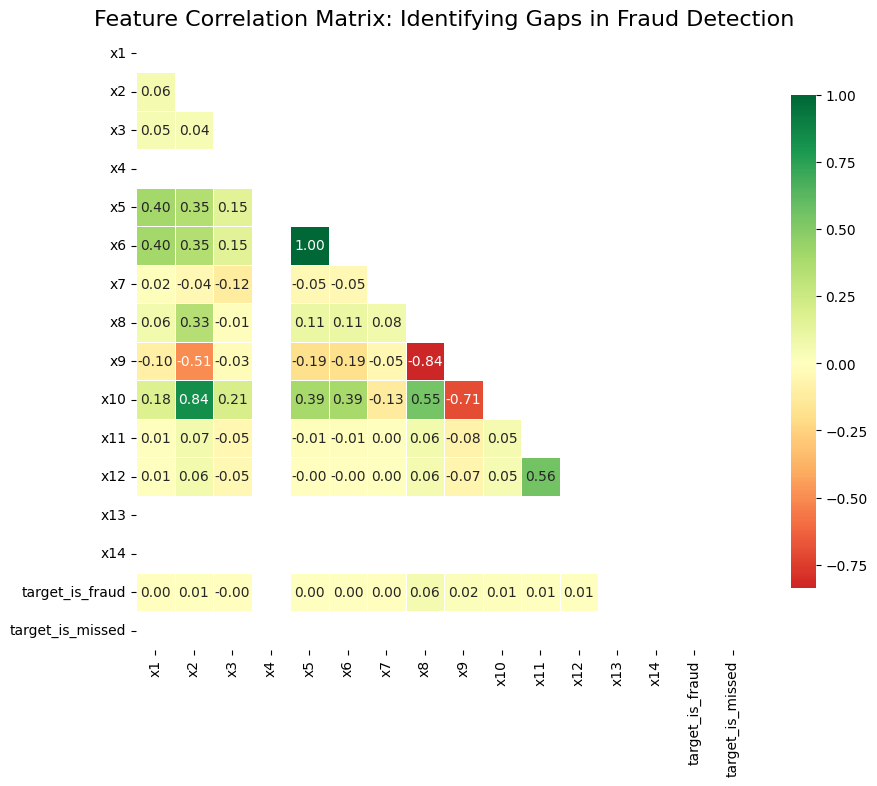

In [31]:
plt.figure(figsize=(10, 8))

# Create a mask for the upper triangle (optional, for cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix: Identifying Gaps in Fraud Detection', fontsize=16)
plt.show()

In [32]:
feature_map_df.show(truncate=False)

+------------+---------------------------+-------------------------+
|feature_name|feature_description        |as_of_ts                 |
+------------+---------------------------+-------------------------+
|x1          |Transaction Amount         |2026-06-02 14:00:02.51652|
|x2          |Transaction Hour           |2026-06-02 14:00:02.51652|
|x3          |Day of Week                |2026-06-02 14:00:02.51652|
|x4          |Cross-Bank Indicator       |2026-06-02 14:00:02.51652|
|x5          |Is Round 100 Amount        |2026-06-02 14:00:02.51652|
|x6          |Is Whole Number            |2026-06-02 14:00:02.51652|
|x7          |Existing Priority Score    |2026-06-02 14:00:02.51652|
|x8          |Rule Band Count            |2026-06-02 14:00:02.51652|
|x9          |Rule Band 01 Upper Limit   |2026-06-02 14:00:02.51652|
|x10         |Rule Band 02 Upper Limit   |2026-06-02 14:00:02.51652|
|x11         |Typology Alert Threshold   |2026-06-02 14:00:02.51652|
|x12         |Number of Rules in T

In [33]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window


w = Window.partitionBy("feature_name").orderBy(F.col("as_of_ts").desc())

feature_map = (
    feature_map_df
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .select("feature_name", "feature_description")
)

feature_map = dict(
    feature_map
    .toPandas()
    .set_index("feature_name")["feature_description"]
    .to_dict()
)

print(feature_map.get("x8"))
print(len(feature_map), "features in map")


Rule Band Count
14 features in map


In [34]:
fn_correlations = corr_matrix['target_is_missed'].sort_values(ascending=False)

print(f"{'='*60}")
print("TOP FEATURES CORRELATED WITH MISSED FRAUD (FN)")
print(f"{'='*60}")
for feature, value in fn_correlations.items():
    if feature != 'target_is_missed':
        desc = feature_map.get(feature, "Unknown")
        print(f"{feature} ({desc}): {value:.4f}")

TOP FEATURES CORRELATED WITH MISSED FRAUD (FN)
x1 (Transaction Amount): nan
x2 (Transaction Hour): nan
x3 (Day of Week): nan
x4 (Cross-Bank Indicator): nan
x5 (Is Round 100 Amount): nan
x6 (Is Whole Number): nan
x7 (Existing Priority Score): nan
x8 (Rule Band Count): nan
x9 (Rule Band 01 Upper Limit): nan
x10 (Rule Band 02 Upper Limit): nan
x11 (Typology Alert Threshold): nan
x12 (Number of Rules in Typology): nan
x13 (Rule 01 Weight in Typology): nan
x14 (Bank-Level TX Count): nan
target_is_fraud (Unknown): nan


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

In [36]:
pdf = discovery_table_for_eda.toPandas()

# Create binary targets for analysis
# target_is_missed: The specific target for "Hidden Fraud" (FN)
pdf['target_is_missed'] = pdf['outcome_category'].apply(lambda x: 1 if x == 'FN' else 0)
pdf['is_fraud_actual'] = pdf['outcome_category'].apply(lambda x: 1 if x in ['TP', 'FN'] else 0)
pdf['is_fraud_predicted'] = pdf['outcome_category'].apply(lambda x: 1 if x in ['TP', 'FP'] else 0)

# FEATURE ENGINEERING & CLEANING
# Dropping features with 0 variance (based on previous heatmap analysis) to reduce noise
drop_cols = [] 
active_features = [f'x{i}' for i in range(1, 15) if f'x{i}' not in drop_cols]

print(f"Data Loaded. Active Features for Analysis: {active_features}")

Data Loaded. Active Features for Analysis: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14']


In [37]:
feature_names = active_features

/usr/local/lib/python3.9/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.9/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


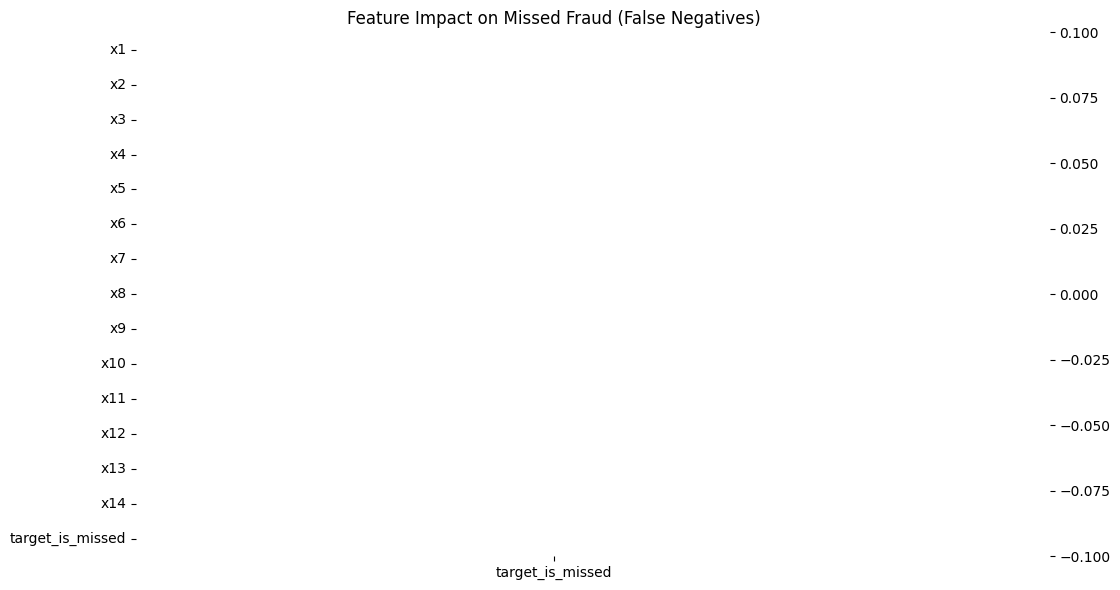

In [38]:
corr_data = pdf[active_features + ['target_is_missed']]
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix[['target_is_missed']].sort_values(by='target_is_missed', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title("Feature Impact on Missed Fraud (False Negatives)")
plt.tight_layout()
plt.show()

In [39]:
model_data = pdf[pdf['outcome_category'].isin(['TP', 'FN'])].copy()
model_data['is_missed'] = (model_data['outcome_category'] == 'FN').astype(int)

X = model_data[active_features]
y = model_data['is_missed']

# XGBoost Model
if model_data.empty or y.nunique() <= 1:
    print('Skipping model training and SHAP: insufficient labeled data (TP/FN missing or single-class target)')
    model = None
    explainer = None
    shap_values = None
    fn_indices = np.array([], dtype=int)
    fn_shap_values = np.empty((0, len(active_features)))
    fn_data_raw = X.iloc[fn_indices]
else:
    model = xgb.XGBClassifier(eval_metric='auc', use_label_encoder=False)
    model.fit(X, y)

    # SHAP Explainer
    explainer = shap.Explainer(model)
    shap_values = explainer(X)

    # Filter SHAP values for just the Missed Frauds (FN)
    fn_indices = np.where(y == 1)[0]
    fn_shap_values = shap_values.values[fn_indices]
    fn_data_raw = X.iloc[fn_indices]

    if len(fn_indices) > 0:
        plt.figure()
        shap.summary_plot(fn_shap_values, fn_data_raw, plot_type='bar', show=False)
        plt.title('Top Drivers for Missed Fraud')
        plt.show()

Skipping model training and SHAP: insufficient labeled data (TP/FN missing or single-class target)


In [40]:
print("Target unique values:", y.unique())
print("Target dtype:", y.dtype)
print("Any NaNs?", y.isna().sum())

Target unique values: [0]
Target dtype: int64
Any NaNs? 0


In [41]:
if fn_shap_values is None or len(fn_shap_values) == 0:
    print("No False Negative samples found — clustering skipped.")
    shap_scaled    = np.empty((0, len(active_features)))
    cluster_labels = np.array([], dtype=int)
    clusterer      = None
    results_df     = fn_data_raw.copy()
    results_df['Cluster_ID']       = pd.Series(dtype=int)
    results_df['Typology_Name']    = pd.Series(dtype=str)
    results_df['Cluster_Confidence'] = pd.Series(dtype=float)
else:
    scaler = StandardScaler()
    # We use the SHAP values for clustering because they represent the *behavioral* reason
    shap_scaled    = scaler.fit_transform(fn_shap_values)
    # HDBSCAN with parameters tuned for small, dense pockets of fraud
    clusterer      = HDBSCAN(min_cluster_size=3, min_samples=2)
    cluster_labels = clusterer.fit_predict(shap_scaled)
    results_df     = fn_data_raw.copy()
    results_df['Cluster_ID']       = cluster_labels
    results_df['Typology_Name']    = results_df['Cluster_ID'].apply(
        lambda x: f"Hidden_Typology_{x}" if x >= 0 else "Noise"
    )
    results_df['Cluster_Confidence'] = clusterer.probabilities_

No False Negative samples found — clustering skipped.


In [42]:
if results_df.empty:
    print("No FN samples — cluster diagnostics skipped.")
    cluster_sizes = pd.Series(dtype=int, name='Cluster_ID')
else:
    labels = results_df["Cluster_ID"].values
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ct = int((labels == -1).sum())
    print(f"Clusters found: {n_clusters}")
    print(f"Noise points: {noise_ct} ({noise_ct/len(labels):.1%})")  # no div-by-zero since we checked empty above

    cluster_sizes = (
        results_df[results_df["Cluster_ID"] != -1]
        .groupby("Cluster_ID")
        .size()
        .sort_values(ascending=False)
    )
    print("\nCluster sizes:")
    display(cluster_sizes)

No FN samples — cluster diagnostics skipped.


In [43]:
if clusterer is not None:
    results_df["Cluster_Confidence"] = clusterer.probabilities_
else:
    print("No clusterer available — Cluster_Confidence skipped.")

No clusterer available — Cluster_Confidence skipped.


In [44]:
if shap_scaled.shape[0] < 4:
    print("Not enough FN samples for UMAP visualisation (need ≥ 4) — skipped.")
else:
    import umap
    n_neighbors = min(10, shap_scaled.shape[0] - 1)  # can't exceed n_samples - 1
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, metric="euclidean", random_state=42)
    embedding = reducer.fit_transform(shap_scaled)

    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels, cmap="tab20", s=20, alpha=0.85)
    plt.title("FN Clusters in SHAP Space (UMAP)")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

Not enough FN samples for UMAP visualisation (need ≥ 4) — skipped.


In [45]:
import builtins

In [46]:
def show_cluster_examples(results_df, cluster_id, n=8):
    print(f"\n--- Cluster {cluster_id} examples (top {n} by confidence) ---")
    display(
        results_df[results_df["Cluster_ID"] == cluster_id]
        .sort_values("Cluster_Confidence", ascending=False)
        .head(n)
    )

if cluster_sizes.empty:
    print("No clusters available — skipped.")
else:
    for cid in cluster_sizes.index[:builtins.min(5, len(cluster_sizes))]:
        show_cluster_examples(results_df, cid, n=8)


No clusters available — skipped.


In [47]:
# SHAP DF for FNs only (aligned with results_df index)
if len(fn_shap_values) == 0:
    print("No FN samples — shap_fn_df will be empty.")
    shap_fn_df = pd.DataFrame(columns=active_features)
else:
    shap_fn_df = pd.DataFrame(fn_shap_values, columns=active_features, index=fn_data_raw.index)

def cluster_typology_cards(results_df, shap_fn_df, pdf, top_k=5):
    _empty = pd.DataFrame(columns=["Cluster_ID","n_FNs","avg_confidence","top_shap_drivers","feature_deltas_vs_global"])
    _empty = _empty.astype({
        "Cluster_ID": "int64", "n_FNs": "int64", "avg_confidence": "float64",
        "top_shap_drivers": "object", "feature_deltas_vs_global": "object",
    })

    if results_df.empty or shap_fn_df.empty:
        print("No FN clusters — returning empty typology cards.")
        return _empty

    cards = []
    for cid in sorted(results_df["Cluster_ID"].unique()):
        if cid == -1:
            continue
        idx = results_df.index[results_df["Cluster_ID"] == cid]
        n = len(idx)
        mean_abs = shap_fn_df.loc[idx].abs().mean().sort_values(ascending=False)
        top_feats = mean_abs.head(top_k).index.tolist()
        deltas = []
        for f in top_feats:
            c_mean = results_df.loc[idx, f].mean()
            g_mean = pdf[f].mean()
            direction = "HIGH" if c_mean > g_mean else "LOW"
            deltas.append(
                f"{f}({feature_map.get(f,f)}): {direction} (cluster={c_mean:.3f}, global={g_mean:.3f})"
            )
        cards.append({
            "Cluster_ID": cid,
            "n_FNs": n,
            "avg_confidence": float(results_df.loc[idx, "Cluster_Confidence"].mean()),
            "top_shap_drivers": ", ".join([f"{f}({feature_map.get(f,f)})" for f in top_feats]),
            "feature_deltas_vs_global": " | ".join(deltas),
        })

    df = pd.DataFrame(cards)
    if df.empty:
        return _empty
    return df.sort_values(["n_FNs"], ascending=False)

typology_cards_df = cluster_typology_cards(results_df, shap_fn_df, pdf, top_k=5)
display(typology_cards_df)

No FN samples — shap_fn_df will be empty.
No FN clusters — returning empty typology cards.


,Cluster_ID,n_FNs,avg_confidence,top_shap_drivers,feature_deltas_vs_global


In [48]:
# Full evaluation frame (includes TN/FP too)
eval_df = pdf.copy()

y_true = eval_df["is_fraud_actual"].values.astype(int)
baseline_pred = eval_df["is_fraud_predicted"].values.astype(int)

def eval_preds(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "alert_rate": float(np.mean(y_pred))
    }

In [49]:
baseline_metrics = eval_preds(y_true, baseline_pred)
print("Baseline metrics:", baseline_metrics)

Baseline metrics: {'TP': 111150, 'FP': 0, 'TN': 4, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'alert_rate': 0.9999640138906382}


In [50]:
def find_best_threshold_rule(
    df, feature, direction,
    y_true, baseline_pred,
    quantiles=(0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99),
    max_extra_alert_rate=0.02,
    max_rule_fire_rate=0.20,     # rule itself shouldn't trigger on >20% of population
    min_rule_fire_rate=0.0005    # don't bother if it triggers on ~0%
):
    best = None

    # numeric coercion (very important after new rows/joins)
    x = pd.to_numeric(df[feature], errors="coerce").values
    x_nonan = x[~np.isnan(x_nonan := x)]  # keeps x_nonan as non-nan view

    # if feature is empty or basically constant, no usable threshold rule
    if x_nonan.size == 0:
        return None
    if np.nanmin(x_nonan) == np.nanmax(x_nonan):
        return None

    base_rate = float(np.mean(baseline_pred))

    # quantile thresholds (dedupe them so we don't re-test the same thr)
    thrs = []
    for q in quantiles:
        thr = float(np.nanquantile(x, q))
        if not np.isnan(thr):
            thrs.append(thr)
    thrs = sorted(set(thrs))

    for thr in thrs:
        # IMPORTANT: use strict comparisons to avoid "everything triggers"
        if direction == "gt":
            rule_trigger = (pd.to_numeric(df[feature], errors="coerce").values > thr).astype(int)
            logic = f"{feature} > {thr:.6g}"
        else:
            rule_trigger = (pd.to_numeric(df[feature], errors="coerce").values < thr).astype(int)
            logic = f"{feature} < {thr:.6g}"

        rule_rate = float(rule_trigger.mean())
        if rule_rate > max_rule_fire_rate or rule_rate < min_rule_fire_rate:
            continue

        new_pred = np.maximum(baseline_pred, rule_trigger)
        m = eval_preds(y_true, new_pred)

        extra_alert_rate = m["alert_rate"] - base_rate
        if extra_alert_rate > max_extra_alert_rate:
            continue

        score = (m["recall"], m["precision"], m["f1"])
        if best is None or score > best["score"]:
            best = {
                "feature": feature,
                "direction": direction,
                "threshold": float(thr),
                "logic": logic,
                "metrics": m,
                "extra_alert_rate": float(extra_alert_rate),
                "rule_fire_rate": rule_rate,
                "score": score
            }

    return best

In [51]:
candidate_rules = []

if results_df.empty:
    print("No FN clusters — skipping candidate rule generation.")
    cluster_sizes = pd.Series(dtype=int, name='Cluster_ID')
else:
    cluster_sizes = (
        results_df[results_df["Cluster_ID"] != -1]
        .groupby("Cluster_ID")
        .size()
        .sort_values(ascending=False)
    )

No FN clusters — skipping candidate rule generation.


In [52]:
if cluster_sizes.empty:
    print("No clusters — rule generation loop skipped.")
else:
    for cid in cluster_sizes.index:
        cluster_idx = results_df.index[results_df["Cluster_ID"] == cid]
        top_feats = (
            shap_fn_df.loc[cluster_idx].abs().mean()
            .sort_values(ascending=False)
            .head(5)
            .index.tolist()
        )
        for feat in top_feats:
            c_med = results_df.loc[cluster_idx, feat].median()
            g_med = eval_df[feat].median()
            direction = "gt" if c_med > g_med else "lt"
            best = find_best_threshold_rule(
                df=eval_df,
                feature=feat,
                direction=direction,
                y_true=y_true,
                baseline_pred=baseline_pred,
                max_extra_alert_rate=0.02
            )
            if best:
                row = {
                    "cluster_id": int(cid),
                    "rule_name": f"DS_Gen_Rule_C{cid}_{feat}",
                    "logic": best["logic"],
                    "feature_description": feature_map.get(feat, feat),
                    "extra_alert_rate": best["extra_alert_rate"],
                    **best["metrics"]
                }
                candidate_rules.append(row)

No clusters — rule generation loop skipped.


In [53]:
if not candidate_rules:
    print("No candidate rules generated.")
    candidates_df = pd.DataFrame()
else:
    candidates_df = pd.DataFrame(candidate_rules).sort_values(
        ["recall", "precision", "f1"], ascending=False
    )
    display(candidates_df.head(25))

No candidate rules generated.


In [54]:
print("DISCOVERY ENGINE: CANDIDATE RULE REPORT")
print("=" * 60)

generated_rules = []
fn_total = len(pdf[pdf["outcome_category"] == "FN"])

if results_df.empty:
    print("No False Negatives in dataset — no rules generated.")
else:
    allowed_feats = [c for c in active_features if c in results_df.columns and c in pdf.columns]

    for cluster_id in sorted(results_df["Cluster_ID"].unique()):
        if cluster_id == -1:
            continue
        subset = results_df[results_df["Cluster_ID"] == cluster_id]
        size = len(subset)
        top_feats = (
            subset[allowed_feats]
            .std(numeric_only=True)
            .sort_values(ascending=False)
            .head(2)
            .index.tolist()
        )
        rule_logic = []
        explanation = f"Cluster {cluster_id} (n={size}): "
        for feat in top_feats:
            feat_desc = feature_map.get(feat, feat)
            mean_val = subset[feat].mean()
            global_mean = pdf[feat].mean()
            if mean_val > global_mean:
                rule_logic.append(f"{feat} - {feat_desc} > {mean_val:.2f}")
                explanation += f"High {feat_desc} ({mean_val:.2f}); "
            else:
                rule_logic.append(f"{feat} - {feat_desc} < {mean_val:.2f}")
                explanation += f"Low {feat_desc} ({mean_val:.2f}); "

        impact_score = (size / fn_total) * 100 if fn_total else 0.0
        rule_proposal = {
            "rule_name": f"DS_Gen_Rule_C{cluster_id}",
            "description": f"Auto-generated rule for {explanation}",
            "logic": " AND ".join(rule_logic),
            "impact_analysis": f"Captures {impact_score:.1f}% of currently missed fraud.",
        }
        generated_rules.append(rule_proposal)
        print(f"📌 {rule_proposal['rule_name']}")
        print(f"   Logic: {rule_proposal['logic']}")
        print(f"   Impact: {rule_proposal['impact_analysis']}")
        print(f"   Context: {rule_proposal['description']}\n")

DISCOVERY ENGINE: CANDIDATE RULE REPORT
No False Negatives in dataset — no rules generated.


In [55]:
def metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "alert_rate": float(np.mean(y_pred)),
    }

# ---- 1) Feature drop justification (variance + nulls) ----
eda_df = pdf.copy()
feat_stats = []
for f in [c for c in pdf.columns if c.startswith("x")]:
    s = pd.to_numeric(eda_df[f], errors="coerce")
    feat_stats.append({
        "feature": f,
        "desc": feature_map.get(f, f),
        "non_null_pct": float(s.notna().mean()),
        "n_unique": int(s.nunique(dropna=True)),
        "std": float(s.std(skipna=True)) if s.notna().any() else np.nan
    })
feat_stats_df = pd.DataFrame(feat_stats).sort_values(["non_null_pct", "n_unique", "std"])
display(feat_stats_df)

# ---- 2) Baseline metrics ----
y_true = pdf["is_fraud_actual"].astype(int).values
baseline_pred = pdf["is_fraud_predicted"].astype(int).values
baseline_m = metrics(y_true, baseline_pred)
print("Baseline metrics:", baseline_m)

# ---- 3) Cluster diagnostics ----
if results_df.empty:
    print("No FN data — cluster diagnostics skipped.")
    n_clusters, noise_pct = 0, 0.0
else:
    labels = results_df["Cluster_ID"].values
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = float(np.mean(labels == -1))
    print(f"Clusters found: {n_clusters}")
    print(f"Noise rate: {noise_pct:.2%}")
    display(
        results_df[results_df["Cluster_ID"] != -1]
        .groupby("Cluster_ID").size()
        .sort_values(ascending=False)
    )

# ---- 4) Typology cards (top SHAP drivers per cluster) ----
if len(fn_shap_values) == 0 or results_df.empty:
    print("No SHAP/FN data — typology cards skipped.")
    typology_cards_df = pd.DataFrame(columns=["Cluster_ID", "n_FNs", "top_shap_drivers", "avg_cluster_confidence"])
else:
    shap_fn_df = pd.DataFrame(fn_shap_values, columns=active_features, index=fn_data_raw.index)
    cards = []
    for cid in sorted(results_df["Cluster_ID"].unique()):
        if cid == -1:
            continue
        idx = results_df.index[results_df["Cluster_ID"] == cid]
        mean_abs = shap_fn_df.loc[idx].abs().mean().sort_values(ascending=False)
        top_feats = mean_abs.head(5).index.tolist()
        cards.append({
            "Cluster_ID": int(cid),
            "n_FNs": int(len(idx)),
            "top_shap_drivers": ", ".join([f"{f}({feature_map.get(f,f)})" for f in top_feats]),
            "avg_cluster_confidence": (
                float(results_df.loc[idx, "Cluster_Confidence"].mean())
                if "Cluster_Confidence" in results_df.columns else np.nan
            )
        })
    typology_cards_df = pd.DataFrame(cards).sort_values("n_FNs", ascending=False)
    display(typology_cards_df)

,feature,desc,non_null_pct,n_unique,std
3,x4,Cross-Bank Indicator,1.0,1,0.000000e+00
12,x13,Rule 01 Weight in Typology,1.0,1,0.000000e+00
13,x14,Bank-Level TX Count,1.0,1,0.000000e+00
4,x5,Is Round 100 Amount,1.0,2,4.839486e-01
5,x6,Is Whole Number,1.0,2,4.839486e-01
8,x9,Rule Band 01 Upper Limit,1.0,3,2.863106e-01
6,x7,Existing Priority Score,1.0,4,1.474360e-01
7,x8,Rule Band Count,1.0,4,3.103330e-01
9,x10,Rule Band 02 Upper Limit,1.0,4,1.651692e+00
2,x3,Day of Week,1.0,5,5.211414e-01


Baseline metrics: {'TP': 111150, 'FP': 0, 'TN': 4, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'alert_rate': 0.9999640138906382}
No FN data — cluster diagnostics skipped.
No SHAP/FN data — typology cards skipped.


### Now Calibration

In [57]:
import matplotlib.pyplot as plt
from pyspark.ml.stat import Correlation

MODEL_OUTPUT_ROOT = "AICAL/models"

PLOT_OUTPUT_DIR = "./typology_calibration_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# Containers to store per-typology artifacts
saved_model_paths = {}     
roc_artifacts = {}         
corr_artifacts = {} 

In [ ]:
import builtins
from pyspark.sql.functions import col, first, from_json, regexp_replace
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.types import DoubleType, LongType, MapType, StringType, StructField, StructType


In [59]:
print("Loading calibration dataset...")

df = final_dataset

Loading calibration dataset...


In [60]:
print("\nPreparing data per typology...")

# Get unique typologies
typologies = df.select("typology_id", "tenant_id").distinct().collect()

print(f"Found {len(typologies)} unique typology-tenant combinations")

# Store results for all typologies
all_results = []


Preparing data per typology...
Found 2 unique typology-tenant combinations


In [61]:
print(typologies)

[Row(typology_id='typology-processor@1.0.0', tenant_id='TAZAMA'), Row(typology_id='typology-processor@1.0.0', tenant_id='PAYSYSLABS')]


In [62]:
from pyspark.ml.functions import vector_to_array

In [63]:
for typ in typologies:
    typology_id = typ["typology_id"]
    tenant_id = typ["tenant_id"]

    print(f"\n{'='*70}")
    print(f"CALIBRATING: {typology_id} (Tenant: {tenant_id})")
    print(f"{'='*70}")

    # Filter data for this typology
    typology_data = df.filter(
        (col("typology_id") == typology_id) & 
        (col("tenant_id") == tenant_id)
    )

    print(f"Records for this typology: {typology_data.count()}")

    typology_data = typology_data.withColumn("rule_id", regexp_replace(col("rule_id"), "\\.", "_"))

    # =====================================
    # STEP 3.1: Pivot rule weights to features
    # =====================================
    print("\nPivoting rule weights into feature vectors...")

    # Get all unique rules for this typology
    rules = typology_data.select("rule_id").distinct().rdd.flatMap(lambda x: x).collect()
    print(f"Rules in this typology: {len(rules)}")
    print(f"Rules: {rules}")

    # Pivot: one row per alert with all rule weights as columns
    pivot_data = typology_data.groupBy(
        "alert_id",
        "is_true_positive",
        "typology_score",
        "alert_threshold",
        "interdiction_threshold",
        "tx_amount",
        "is_high_value_tx",
        "is_cross_border",
        "priority_score"
    ).pivot("rule_id").agg(first("current_rule_weight"))

    # Fill nulls with 0 (rules that didn't fire)
    # Build fillna dict with all pivoted columns
    fill_dict = {}
    for rule in rules:
        # Check if column exists (pivot creates column names as-is)
        if rule in pivot_data.columns:
            fill_dict[rule] = 0

    # Fill all at once
    if fill_dict:
        pivot_data = pivot_data.fillna(fill_dict)

    # Remove records with null target
    pivot_data = pivot_data.filter(col("is_true_positive").isNotNull())

    print(f"Pivoted data records: {pivot_data.count()}")

    # Check label diversity in pivoted data (avoid single-class training)
    pivot_label_count = pivot_data.select("is_true_positive").distinct().count()
    if pivot_label_count < 2:
        print(f"Typology {typology_id} has only {pivot_label_count} label(s) in pivot_data; skipping training to avoid single-class model.")
        continue

    # Check if we have enough data
    if pivot_data.count() < 10:
        print(f"Insufficient data for {typology_id}, skipping...")
        continue

    # =====================================
    # STEP 3.2: Create feature vectors
    # =====================================
    print("\nCreating feature vectors...")

    # Get actual column names from pivot (they might have @ symbols)
    pivot_columns = pivot_data.columns

    # Rule columns are those not in our base columns
    base_cols = ["alert_id", "is_true_positive", "typology_score", "alert_threshold", 
                 "interdiction_threshold", "tx_amount", "is_high_value_tx", 
                 "is_cross_border", "priority_score"]

    rule_feature_cols = [c for c in pivot_columns if c not in base_cols]

    # Select feature columns (rule weights + transaction features)
    feature_cols = rule_feature_cols + [
        "tx_amount",
        "is_high_value_tx",
        "is_cross_border",
        "priority_score"
    ]

    # Ensure all feature columns exist and handle nulls
    feature_cols = [c for c in feature_cols if c in pivot_data.columns]

    # Fill any remaining nulls in feature columns
    for col_name in feature_cols:
        pivot_data = pivot_data.fillna({col_name: 0.0})

    print(f"Using {len(feature_cols)} features")
    print(f"Rule features: {len(rule_feature_cols)}")
    print("Transaction features: 4")

    # Assemble features into vector
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features",
        handleInvalid="skip"
    )

    # Scale features
    scaler = StandardScaler(
        inputCol="features",
        outputCol="scaled_features",
        withStd=True,
        withMean=True
    )

    # =====================================
    # STEP 3.3: Split data
    # =====================================
    print("\nSplitting data into train/test...")

    train_data, test_data = pivot_data.randomSplit([0.8, 0.2], seed=42)

    print(f"Training records: {train_data.count()}")
    print(f"Testing records: {test_data.count()}")

    # Verify both train and test contain at least two distinct labels
    train_labels = [r[0] for r in train_data.select("is_true_positive").distinct().collect()]
    test_labels = [r[0] for r in test_data.select("is_true_positive").distinct().collect()]
    if len(train_labels) < 2 or len(test_labels) < 2:
        print(f"Typology {typology_id} produced train/test split missing a class. Train labels: {train_labels}, Test labels: {test_labels}. Skipping training.")
        continue

    # =====================================
    # STEP 3.4: Train Logistic Regression
    # =====================================
    print("\nTraining Logistic Regression model...")

    # Create logistic regression model
    lr = LogisticRegression(
        featuresCol="scaled_features",
        labelCol="is_true_positive",
        maxIter=100,
        regParam=0.01,  # L2 regularization
        elasticNetParam=0.5,  # Mix of L1 and L2
        family="binomial"
    )

    # Create pipeline
    pipeline = Pipeline(stages=[assembler, scaler, lr])

    # Train model
    print("Fitting model...")
    model = pipeline.fit(train_data)

    # ==========================
    # STEP 3.4.1: Save model (ADDED)
    # ==========================
    model_path = f"{MODEL_OUTPUT_ROOT}/typology_id={typology_id}/tenant_id={tenant_id}"
    model.write().overwrite().save(model_path)
    saved_model_paths[(typology_id, tenant_id)] = model_path
    print(f"Saved Spark ML PipelineModel to: {model_path}")

    # =====================================
    # STEP 3.5: Evaluate model
    # =====================================
    print("\nEvaluating model...")

    # Get predictions
    train_predictions = model.transform(train_data)
    test_predictions = model.transform(test_data)

    # Evaluate
    evaluator = BinaryClassificationEvaluator(
        labelCol="is_true_positive",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    train_auc = evaluator.evaluate(train_predictions)
    test_auc = evaluator.evaluate(test_predictions)

    print(f"Training AUC: {train_auc:.4f}")
    print(f"Testing AUC: {test_auc:.4f}")

    # =====================================
    # STEP 3.5.1: ROC curve (ADDED)
    # =====================================
    # Collect probability + label for ROC plotting
    roc_pdf = test_predictions.select(
        col("is_true_positive").cast("double").alias("y"),
        vector_to_array(col("probability")).getItem(1).cast("double").alias("p")
    ).toPandas()

    # Guard against edge cases where only one class exists in test split
    if roc_pdf["y"].nunique() >= 2:
        # sklearn is usually available; if not, we fallback to a tiny manual implementation
        try:
            from sklearn.metrics import roc_curve, auc
            fpr, tpr, _ = roc_curve(roc_pdf["y"].values, roc_pdf["p"].values)
            roc_auc = auc(fpr, tpr)
        except Exception:
            # Fallback: basic ROC computation (not as optimized)
            thresholds = np.unique(roc_pdf["p"].values)[::-1]
            P = (roc_pdf["y"] == 1).sum()
            N = (roc_pdf["y"] == 0).sum()
            tpr = []
            fpr = []
            for thr in thresholds:
                pred = (roc_pdf["p"].values >= thr).astype(int)
                TP = ((pred == 1) & (roc_pdf["y"].values == 1)).sum()
                FP = ((pred == 1) & (roc_pdf["y"].values == 0)).sum()
                tpr.append(TP / P if P else 0.0)
                fpr.append(FP / N if N else 0.0)
            fpr = np.array([0.0] + fpr + [1.0])
            tpr = np.array([0.0] + tpr + [1.0])
            roc_auc = np.trapz(tpr, fpr)

        roc_artifacts[(typology_id, tenant_id)] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    # Calculate additional metrics
    test_metrics = test_predictions.select(
        "is_true_positive",
        "prediction"
    )

    tp = test_metrics.filter((col("is_true_positive") == 1) & (col("prediction") == 1.0)).count()
    fp = test_metrics.filter((col("is_true_positive") == 0) & (col("prediction") == 1.0)).count()
    tn = test_metrics.filter((col("is_true_positive") == 0) & (col("prediction") == 0.0)).count()
    fn = test_metrics.filter((col("is_true_positive") == 1) & (col("prediction") == 0.0)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print("\nTest Set Metrics:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")

    # =====================================
    # STEP 3.5.2: Correlation matrix (ADDED)
    # =====================================
    # Correlation on scaled_features (vector)
    corr_row = Correlation.corr(train_predictions.select("scaled_features"), "scaled_features", "pearson").head()
    corr_matrix = corr_row[0]  # DenseMatrix
    corr_np = np.array(corr_matrix.toArray())
    corr_artifacts[(typology_id, tenant_id)] = {"matrix": corr_np, "features": feature_cols}

    # =====================================
    # STEP 3.6: Extract coefficients (weights)
    # =====================================
    print("\nExtracting model coefficients...")

    # Get the trained logistic regression model
    lr_model = model.stages[-1]
    coefficients = lr_model.coefficients.toArray()
    intercept = lr_model.intercept

    print(f"Model intercept: {intercept:.4f}")

    # Map coefficients back to features
    rule_coefficients = {}

    for i, feature_name in enumerate(feature_cols):
        coef = coefficients[i]
        rule_coefficients[feature_name] = float(coef)

    # Separate rule coefficients from transaction feature coefficients
    rule_only_coefficients = {k: v for k, v in rule_coefficients.items() 
                             if k in rule_feature_cols}

    # =====================================
    # STEP 3.7: Calculate current baseline metrics
    # =====================================
    print("\nCalculating current baseline metrics...")

    current_tp = typology_data.filter(col("is_true_positive") == 1).count()
    current_fp = typology_data.filter(col("is_false_positive") == 1).count()
    current_tn = typology_data.filter(col("is_true_negative") == 1).count()
    current_fn = typology_data.filter(col("is_false_negative") == 1).count()

    current_precision = current_tp / (current_tp + current_fp) if (current_tp + current_fp) > 0 else 0
    current_recall = current_tp / (current_tp + current_fn) if (current_tp + current_fn) > 0 else 0
    current_f1 = 2 * current_precision * current_recall / (current_precision + current_recall) if (current_precision + current_recall) > 0 else 0

    print("\nCurrent Performance:")
    print(f"  Precision: {current_precision:.4f}")
    print(f"  Recall: {current_recall:.4f}")
    print(f"  F1 Score: {current_f1:.4f}")

    # =====================================
    # STEP 3.8: Generate weight recommendations
    # =====================================
    print("\nGenerating weight recommendations...")

    # Get current weights for each rule
    current_weights = {}
    for rule in rule_feature_cols:
        # Get average current weight for this rule across all alerts
        avg_weight = typology_data.filter(col("rule_id") == rule).agg(
            avg("current_rule_weight")
        ).first()
        
        if avg_weight and avg_weight[0] is not None:
            current_weights[rule] = float(avg_weight[0])
        else:
            current_weights[rule] = 0.0

    # Calculate recommended weights based on coefficients
    recommendations = {}

    for rule in rule_feature_cols:
        if rule not in rule_only_coefficients:
            continue
            
        coef = rule_only_coefficients[rule]
        current_weight = current_weights.get(rule, 0)
        
        # Strategy: Adjust weight based on coefficient magnitude
        # Positive coefficient = good predictor of true positives (increase weight)
        # Negative coefficient = bad predictor (decrease weight)
        
        # Scale adjustment by coefficient magnitude
        adjustment = int(coef * 100)
        
        # Recommended weight = current + adjustment
        # Replace the problematic lines with these:

# Use builtins.max to avoid Spark collision
        recommended_weight = builtins.max(0, int(current_weight + adjustment))

        # Use builtins.abs to be safe
        if builtins.abs(adjustment) < 10:
            action = "retain"
        elif adjustment > 0:
            action = "increase"
        else:
            action = "decrease"
        
        
        recommendations[rule] = {
            "current_weight": current_weight,
            "coefficient": coef,
            "adjustment": adjustment,
            "recommended_weight": recommended_weight,
            "action": action,
            "explanation": (
                f"Coefficient {coef:.4f} suggests this rule {'positively' if coef > 0 else 'negatively'} "
                f"correlates with true positives. Recommended to {action} weight from "
                f"{current_weight:.0f} to {recommended_weight}."
            )
        }
    
    # Sort by absolute coefficient (most impactful rules first)
    sorted_recommendations = dict(
        sorted(recommendations.items(), key=lambda x: builtins.abs(x[1]['coefficient']), reverse=True)
    )
    
    print("\nTop 5 Most Impactful Rules:")
    for i, (rule, rec) in enumerate(list(sorted_recommendations.items())[:5]):
        print(f"  {i+1}. {rule}: {rec['action']} ({rec['current_weight']:.0f} → {rec['recommended_weight']})")
    
    # =====================================
    # STEP 3.9: Calculate optimal thresholds
    # =====================================
    print("\nCalculating optimal thresholds...")
    
    # Get current thresholds
    current_alert_threshold = typology_data.select("alert_threshold").first()[0]
    current_interdiction_threshold = typology_data.select("interdiction_threshold").first()[0]
    
    # Analyze score distribution for true positives
    tp_scores = typology_data.filter(col("is_true_positive") == 1).select("typology_score")
    fp_scores = typology_data.filter(col("is_false_positive") == 1).select("typology_score")
    
    tp_percentiles = tp_scores.approxQuantile("typology_score", [0.25, 0.5, 0.75, 0.9], 0.01)
    
    # Recommended alert threshold: median of true positives * 0.7
    recommended_alert = int(tp_percentiles[1] * 0.7) if builtins.len(tp_percentiles) > 1 else current_alert_threshold
    
    # Recommended interdiction threshold: 75th percentile of true positives
    recommended_interdiction = int(tp_percentiles[2]) if builtins.len(tp_percentiles) > 2 else current_interdiction_threshold

    print("\nThreshold Recommendations:")
    print(f"  Current Alert: {current_alert_threshold} → Recommended: {recommended_alert}")
    print(f"  Current Interdiction: {current_interdiction_threshold} → Recommended: {recommended_interdiction}")
    
    # =====================================
    # STEP 3.10: Create calibration report
    # =====================================
    
    calibration_report = {
        "calibration_id": f"CAL_{typology_id}_{tenant_id}_{spark.sparkContext.applicationId}",
        "typology_id": typology_id,
        "tenant_id": tenant_id,
        "calibration_timestamp": str(spark.sql("SELECT current_timestamp()").first()[0]),
        
        "model_performance": {
            "train_auc": train_auc,
            "test_auc": test_auc,
            "test_precision": precision,
            "test_recall": recall,
            "test_f1_score": f1
        },
        
        "current_baseline": {
            "precision": current_precision,
            "recall": current_recall,
            "f1_score": current_f1,
            "true_positives": current_tp,
            "false_positives": current_fp,
            "true_negatives": current_tn,
            "false_negatives": current_fn
        },
        
        "rule_recommendations": sorted_recommendations,
        
        "threshold_recommendations": {
            "current_alert_threshold": current_alert_threshold,
            "recommended_alert_threshold": recommended_alert,
            "alert_threshold_change": recommended_alert - current_alert_threshold,
            "current_interdiction_threshold": current_interdiction_threshold,
            "recommended_interdiction_threshold": recommended_interdiction,
            "interdiction_threshold_change": recommended_interdiction - current_interdiction_threshold
        },
        
        "summary": {
            "total_rules": len(rule_feature_cols),
            "rules_to_increase": len([r for r in recommendations.values() if r["action"] == "increase"]),
            "rules_to_decrease": len([r for r in recommendations.values() if r["action"] == "decrease"]),
            "rules_to_retain": len([r for r in recommendations.values() if r["action"] == "retain"]),
            "expected_f1_improvement": f1 - current_f1
        }
    }

    all_results.append(calibration_report)

    # =====================================
    # STEP 3.11: Display detailed report
    # =====================================

    print(f"\n{'='*70}")
    print(f"CALIBRATION REPORT: {typology_id}")
    print(f"{'='*70}")

    print("MODEL PERFORMANCE:")
    print(f"  Test AUC: {test_auc:.4f}")
    print(f"  Test F1:  {f1:.4f}")

    print("CURRENT vs EXPECTED:")
    print(f"  Current F1:  {current_f1:.4f}")
    print(f"  Expected F1: {f1:.4f}")
    print(f"  Improvement: {(f1 - current_f1):.4f} ({((f1 - current_f1) / current_f1 * 100) if current_f1 > 0 else 0:.2f}% )")

    print("RULE RECOMMENDATIONS:")
    print(f"  Increase: {calibration_report['summary']['rules_to_increase']} rules")
    print(f"  Decrease: {calibration_report['summary']['rules_to_decrease']} rules")
    print(f"  Retain:   {calibration_report['summary']['rules_to_retain']} rules")

    print("\n⚡ THRESHOLD RECOMMENDATIONS:")
    print(f"  Alert:        {current_alert_threshold} → {recommended_alert} ({recommended_alert - current_alert_threshold:+d})")
    print(f"  Interdiction: {current_interdiction_threshold} → {recommended_interdiction} ({recommended_interdiction - current_interdiction_threshold:+d})")



CALIBRATING: typology-processor@1.0.0 (Tenant: TAZAMA)


Records for this typology: 71868

Pivoting rule weights into feature vectors...
Rules in this typology: 34
Rules: ['063@1_0_0', '020@1_0_0', '076@1_0_0', '021@1_0_0', '001@1_0_0', '011@1_0_0', '048@1_0_0', '028@1_0_0', 'EFRuP@1_0_0', '030@1_0_0', '008@1_0_0', '002@1_0_0', '090@1_0_0', '074@1_0_0', '018@1_0_0', '004@1_0_0', '016@1_0_0', '044@1_0_0', '017@1_0_0', '091@1_0_0', '010@1_0_0', '024@1_0_0', '006@1_0_0', '026@1_0_0', '025@1_0_0', '084@1_0_0', '007@1_0_0', '045@1_0_0', '027@1_0_0', '078@1_0_0', '003@1_0_0', '054@1_0_0', '083@1_0_0', '075@1_0_0']


Pivoted data records: 5944
Typology typology-processor@1.0.0 has only 1 label(s) in pivot_data; skipping training to avoid single-class model.

CALIBRATING: typology-processor@1.0.0 (Tenant: PAYSYSLABS)
Records for this typology: 776832

Pivoting rule weights into feature vectors...
Rules in this typology: 34
Rules: ['063@1_0_0', '076@1_0_0', '020@1_0_0', '001@1_0_0', '021@1_0_0', '028@1_0_0', '048@1_0_0', '011@1_0_0', 'EFRuP@1_0_0', '030@1_0_0', '008@1_0_0', '090@1_0_0', '002@1_0_0', '074@1_0_0', '018@1_0_0', '004@1_0_0', '091@1_0_0', '044@1_0_0', '016@1_0_0', '017@1_0_0', '010@1_0_0', '024@1_0_0', '006@1_0_0', '025@1_0_0', '026@1_0_0', '007@1_0_0', '084@1_0_0', '045@1_0_0', '027@1_0_0', '078@1_0_0', '003@1_0_0', '083@1_0_0', '054@1_0_0', '075@1_0_0']


[Stage 187:>                                                        (0 + 1) / 1]

Pivoted data records: 357


Typology typology-processor@1.0.0 has only 1 label(s) in pivot_data; skipping training to avoid single-class model.


In [64]:
for (typology_id, tenant_id), roc in roc_artifacts.items():
    plt.figure()

    if len(roc["fpr"]) > 0:
        plt.plot(roc["fpr"], roc["tpr"], label=f"AUC={roc['auc']:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.legend(loc="lower right")
    else:
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.text(0.05, 0.5, "ROC undefined\n(single class)", fontsize=12)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {typology_id} | {tenant_id}")
    plt.show()

In [65]:
for (typology_id, tenant_id), payload in corr_artifacts.items():
    corr = payload["matrix"]
    features = payload["features"]

    plt.figure(figsize=(8, 6))
    plt.imshow(corr)
    plt.colorbar()
    plt.title(f"Feature Correlation — {typology_id} | {tenant_id}")
    plt.xlabel("Feature Index")
    plt.ylabel("Feature Index")
    plt.show()

In [66]:
for (typology_id, tenant_id), payload in corr_artifacts.items():
    corr_df = pd.DataFrame(
        payload["matrix"],
        index=payload["features"],
        columns=payload["features"]
    )
    print(f"\nCorrelation matrix — {typology_id} | {tenant_id}")
    display(corr_df.round(3))


In [67]:
print("SAVING CALIBRATION REPORTS")

# Convert to DataFrame
reports_df = spark.createDataFrame([json.dumps(r) for r in all_results], "string").toDF("report_json")

# Parse JSON back to structured format (use nested types so nested fields are accessible)
reports_df = reports_df.select(from_json(col("report_json"), 
    StructType([
        StructField("calibration_id", StringType()),
        StructField("typology_id", StringType()),
        StructField("tenant_id", StringType()),
        StructField("calibration_timestamp", StringType()),
        StructField("model_performance", StructType([
            StructField("train_auc", DoubleType()),
            StructField("test_auc", DoubleType()),
            StructField("test_precision", DoubleType()),
            StructField("test_recall", DoubleType()),
            StructField("test_f1_score", DoubleType())
        ])),
        StructField("current_baseline", StructType([
            StructField("precision", DoubleType()),
            StructField("recall", DoubleType()),
            StructField("f1_score", DoubleType()),
            StructField("true_positives", LongType()),
            StructField("false_positives", LongType()),
            StructField("true_negatives", LongType()),
            StructField("false_negatives", LongType())
        ])),
        StructField("rule_recommendations", MapType(StringType(), StructType([
            StructField("current_weight", DoubleType()),
            StructField("coefficient", DoubleType()),
            StructField("adjustment", DoubleType()),
            StructField("recommended_weight", DoubleType()),
            StructField("action", StringType()),
            StructField("explanation", StringType())
        ]))),
        StructField("threshold_recommendations", StructType([
            StructField("current_alert_threshold", LongType()),
            StructField("recommended_alert_threshold", LongType()),
            StructField("alert_threshold_change", LongType()),
            StructField("current_interdiction_threshold", LongType()),
            StructField("recommended_interdiction_threshold", LongType()),
            StructField("interdiction_threshold_change", LongType())
        ])),
        StructField("summary", StructType([
            StructField("total_rules", LongType()),
            StructField("rules_to_increase", LongType()),
            StructField("rules_to_decrease", LongType()),
            StructField("rules_to_retain", LongType()),
            StructField("expected_f1_improvement", DoubleType())
        ]))
    ])
).alias("report")).select("report.*")

output_path = "/AICAL/report"
reports_df.write.mode("append").json(output_path)

print(f"Saved {len(all_results)} calibration reports to: {output_path}")


SAVING CALIBRATION REPORTS


[Stage 199:========================>                               (7 + 8) / 16]

Saved 0 calibration reports to: /AICAL/report


In [68]:
print("CALIBRATION SUMMARY - ALL TYPOLOGIES")

for report in all_results:
    print(f"\n{report['typology_id']} ({report['tenant_id']}):")
    print(f"  Current F1: {report['current_baseline']['f1_score']:.4f}")
    print(f"  Expected F1: {report['model_performance']['test_f1_score']:.4f}")
    print(f"  Rules to adjust: {report['summary']['rules_to_increase'] + report['summary']['rules_to_decrease']}")
    print(f"  Model Quality (AUC): {report['model_performance']['test_auc']:.4f}")

print("CALIBRATION COMPLETE!")
print(f"Total typologies calibrated: {len(all_results)}")


CALIBRATION SUMMARY - ALL TYPOLOGIES
CALIBRATION COMPLETE!
Total typologies calibrated: 0


In [69]:
print("\nSaved models:")
for k, v in saved_model_paths.items():
    print(f"  {k}: {v}")

print("\nROC artifacts available for:")
for k, v in roc_artifacts.items():
    print(f"  {k}: AUC={v['auc']:.4f}")

print("\nCorrelation matrices available for:")
for k, v in corr_artifacts.items():
    print(f"  {k}: shape={v['matrix'].shape}, n_features={len(v['features'])}")

if len(corr_artifacts) > 0:
    (typology_id, tenant_id), payload = next(iter(corr_artifacts.items()))
    corr_df = pd.DataFrame(payload["matrix"], index=payload["features"], columns=payload["features"])
    display(corr_df.head(10))



Saved models:

ROC artifacts available for:

Correlation matrices available for:
